In [1]:
import pandas as pd

# Load directly from UCI's public URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

print(df.shape)
print(df.head())
print(df.describe())
print(df['quality'].value_counts().sort_index())

(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [4]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
X = df.drop('quality', axis=1).values  # all columns except quality, as a numpy array
y = df['quality'].values                # just the quality column, as a numpy array

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 80% train, 20% test, fixed seed for reproducibility
)

In [7]:
X_train.shape

(1279, 11)

In [8]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test- mean) / std

In [ ]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

In [10]:
import numpy as np

k = 5
num_val_samples = len(X_train) // k
num_epochs = 100
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = X_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [X_train[: i * num_val_samples], X_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
        validation_data=(fold_x_val, fold_y_val)
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4
Processing fold #5


In [11]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

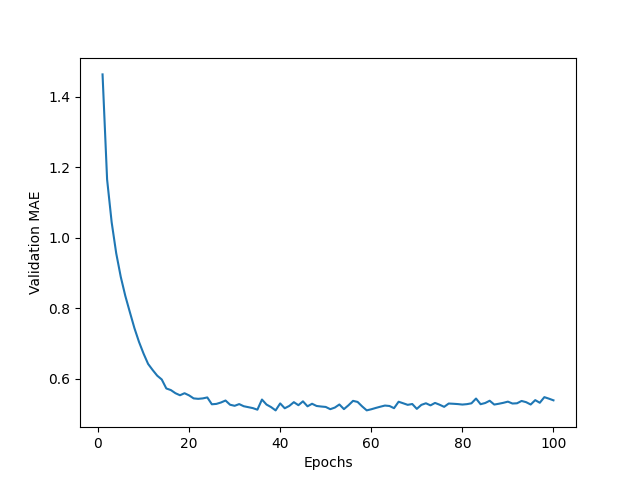

In [12]:
%matplotlib widget
import matplotlib.pyplot as plt
plt.clf()

epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [13]:
model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - loss: 0.3498 - mean_absolute_error: 0.4701


In [15]:
#Adding dropouts


import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

In [16]:
model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.4429 - mean_absolute_error: 0.5231


In [17]:
#Adding dropouts


import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 0.3652 - mean_absolute_error: 0.4946


In [18]:
import numpy as np

k = 5
num_val_samples = len(X_train) // k
num_epochs = 100
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = X_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [X_train[: i * num_val_samples], X_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
        validation_data=(fold_x_val, fold_y_val)
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4
Processing fold #5


In [19]:
#Adding dropouts

model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.4628 - mean_absolute_error: 0.5288


In [26]:
#Adding dropouts


import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            #layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            #layers.Dropout(0.3),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 0.3638 - mean_absolute_error: 0.4806


In [23]:
import numpy as np

k = 5
num_val_samples = len(X_train) // k
num_epochs = 34
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = X_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [X_train[: i * num_val_samples], X_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
        validation_data=(fold_x_val, fold_y_val)
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4
Processing fold #5


In [24]:
model = get_model()
model.fit(X_train, y_train, epochs=34, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    X_test, y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - loss: 0.3850 - mean_absolute_error: 0.4852
